Nombre de vols en retard au départ : 12799

--- STATISTIQUES PAR AÉROPORT ---
  origin  avg_dep_delay  avg_arr_delay  n_flights  rattrapage_moyen  \
0    EWR      39.098098      34.057051       5311          5.041047   
1    JFK      38.729437      33.259981       4158          5.469456   
2    LGA      41.121922      37.691892       3330          3.430030   

   correlation  pct_rattrapage_total  
0     0.943109             26.812276  
1     0.935936             27.465127  
2     0.939765             22.552553  


/tmp/ipython-input-1018393565.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlations = df_clean.groupby('origin').apply(
/tmp/ipython-input-1018393565.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rattrapage_pct = df_clean.groupby('origin').apply(


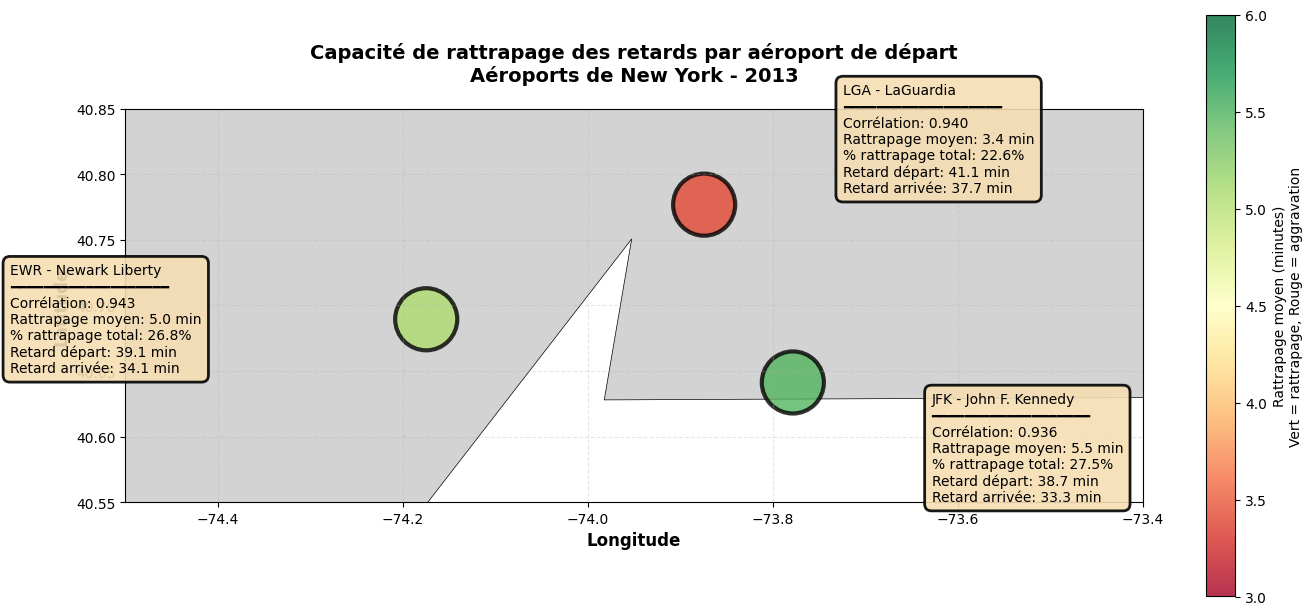


--- ANALYSE COMPARATIVE DES AÉROPORTS ---
------------------------------
EWR - Newark Liberty
------------------------------
Nombre de vols analysés: 5,311
Corrélation départ-arrivée: 0.9431
Retard moyen au départ: 39.10 minutes
Retard moyen à l'arrivée: 34.06 minutes
Rattrapage moyen en vol: 5.04 minutes
% de vols rattrapant totalement: 26.8%
→ Cet aéroport permet en moyenne de RATTRAPER 5.0 minutes
------------------------------
JFK - John F. Kennedy
------------------------------
Nombre de vols analysés: 4,158
Corrélation départ-arrivée: 0.9359
Retard moyen au départ: 38.73 minutes
Retard moyen à l'arrivée: 33.26 minutes
Rattrapage moyen en vol: 5.47 minutes
% de vols rattrapant totalement: 27.5%
→ Cet aéroport permet en moyenne de RATTRAPER 5.5 minutes
------------------------------
LGA - LaGuardia
------------------------------
Nombre de vols analysés: 3,330
Corrélation départ-arrivée: 0.9398
Retard moyen au départ: 41.12 minutes
Retard moyen à l'arrivée: 37.69 minutes
Rattrapage

In [9]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import numpy as np

# CHARGEMENT DES DONNÉES
df = pd.read_csv("nycflights.csv")
df_clean = df[df["dep_delay"] > 0].dropna(subset=['dep_delay', 'arr_delay']).copy()

print(f"Nombre de vols en retard au départ : {len(df_clean)}")

# CALCUL STATISTIQUES PAR AÉROPORT
airport_stats = df_clean.groupby('origin').agg({
    'dep_delay': 'mean',
    'arr_delay': 'mean',
    'flight': 'count'
}).reset_index()

airport_stats.columns = ['origin', 'avg_dep_delay', 'avg_arr_delay', 'n_flights']

# Calculer le taux de rattrapage moyen
# (négatif = aggravation)
airport_stats['rattrapage_moyen'] = airport_stats['avg_dep_delay'] - airport_stats['avg_arr_delay']

# Calculer la corrélation par aéroport
correlations = df_clean.groupby('origin').apply(
    lambda x: x['dep_delay'].corr(x['arr_delay'])
).reset_index()
correlations.columns = ['origin', 'correlation']

airport_stats = airport_stats.merge(correlations, on='origin')

# Calculer le % de vols qui rattrapent complètement
rattrapage_pct = df_clean.groupby('origin').apply(
    lambda x: (x['arr_delay'] < 0).sum() / len(x) * 100
).reset_index()
rattrapage_pct.columns = ['origin', 'pct_rattrapage_total']

airport_stats = airport_stats.merge(rattrapage_pct, on='origin')

print("\n--- STATISTIQUES PAR AÉROPORT ---")
print(airport_stats)

# COORDONNÉES DES AÉROPORTS
airport_coords = {
    "JFK": {"lat": 40.6413, "lon": -73.7781, "name": "John F. Kennedy"},
    "LGA": {"lat": 40.7769, "lon": -73.8740, "name": "LaGuardia"},
    "EWR": {"lat": 40.6895, "lon": -74.1745, "name": "Newark Liberty"},
}

airport_stats['lat'] = airport_stats['origin'].map(lambda x: airport_coords[x]['lat'])
airport_stats['lon'] = airport_stats['origin'].map(lambda x: airport_coords[x]['lon'])
airport_stats['name'] = airport_stats['origin'].map(lambda x: airport_coords[x]['name'])

# CRÉER LE GEODATAFRAME
gdf_airports = gpd.GeoDataFrame(
    airport_stats,
    geometry=[Point(xy) for xy in zip(airport_stats['lon'], airport_stats['lat'])],
    crs="EPSG:4326"
)

# CHARGER LA CARTE
world = gpd.read_file("ne_110m_admin_0_countries.shp")
usa = world[world["NAME"] == "United States of America"]

# CRÉER LE PLOT
fig, ax = plt.subplots(figsize=(14, 10))

# Carte USA en fond (focus sur NYC)
usa.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5)

# Points des aéroports
# Couleur = taux de rattrapage moyen (vert = bon, rouge = mauvais)
scatter = ax.scatter(
    gdf_airports.geometry.x,
    gdf_airports.geometry.y,
    s=2000,  # Gros points pour visibilité
    c=gdf_airports['rattrapage_moyen'],
    cmap='RdYlGn',  # Rouge (aggravation) à Vert (rattrapage)
    alpha=0.8,
    edgecolors='black',
    linewidth=3,
    vmin=3,
    vmax=6
)

# Annotations détaillées pour chaque aéroport
for idx, row in gdf_airports.iterrows():
    # un texte détaillé
    text = f"{row['origin']} - {row['name']}\n"
    text += f"━━━━━━━━━━━━━━━━━━━\n"
    text += f"Corrélation: {row['correlation']:.3f}\n"
    text += f"Rattrapage moyen: {row['rattrapage_moyen']:.1f} min\n"
    text += f"% rattrapage total: {row['pct_rattrapage_total']:.1f}%\n"
    text += f"Retard départ: {row['avg_dep_delay']:.1f} min\n"
    text += f"Retard arrivée: {row['avg_arr_delay']:.1f} min"

    # Position du texte (décalé pour éviter chevauchement)
    if row['origin'] == 'JFK':
        offset_x, offset_y = 0.15, -0.05
    elif row['origin'] == 'LGA':
        offset_x, offset_y = 0.15, 0.05
    else:  # EWR
        offset_x, offset_y = -0.45, 0.0

    ax.text(
        row.geometry.x + offset_x,
        row.geometry.y + offset_y,
        text,
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.9, edgecolor='black', linewidth=2),
        verticalalignment='center'
    )

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, label='Rattrapage moyen (minutes)\nVert = rattrapage, Rouge = aggravation', shrink=0.6)

ax.set_title('Capacité de rattrapage des retards par aéroport de départ\nAéroports de New York - 2013',
             fontsize=14, fontweight='bold', pad=20)

# Zoom sur la zone de NYC
ax.set_xlim([-74.5, -73.4])
ax.set_ylim([40.55, 40.85])
ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')

# Grille
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ANALYSE DÉTAILLÉE
print(f"\n--- ANALYSE COMPARATIVE DES AÉROPORTS ---")
for idx, row in airport_stats.iterrows():
    print(f"{'---'*10}")
    print(f"{row['origin']} - {row['name']}")
    print(f"{'---'*10}")
    print(f"Nombre de vols analysés: {row['n_flights']:,}")
    print(f"Corrélation départ-arrivée: {row['correlation']:.4f}")
    print(f"Retard moyen au départ: {row['avg_dep_delay']:.2f} minutes")
    print(f"Retard moyen à l'arrivée: {row['avg_arr_delay']:.2f} minutes")
    print(f"Rattrapage moyen en vol: {row['rattrapage_moyen']:.2f} minutes")
    print(f"% de vols rattrapant totalement: {row['pct_rattrapage_total']:.1f}%")

    if row['rattrapage_moyen'] > 0:
        print(f"→ Cet aéroport permet en moyenne de RATTRAPER {row['rattrapage_moyen']:.1f} minutes")
    else:
        print(f"→ Cet aéroport aggrave en moyenne le retard de {-row['rattrapage_moyen']:.1f} minutes")

print(f"\n{'---'*10}")
print(f"CONCLUSION GLOBALE")
print(f"{'---'*10}")
best_airport = airport_stats.loc[airport_stats['rattrapage_moyen'].idxmax()]
print(f" Meilleur aéroport pour rattraper: {best_airport['origin']} ({best_airport['rattrapage_moyen']:.1f} min)")
print(f" Corrélation moyenne: {airport_stats['correlation'].mean():.3f}")
print(f" Les 3 aéroports montrent une forte corrélation (>0.94), validant l'hypothèse")